# Propensity Score & DML

- IPW, AIPW, Doubly Robust Estimator

### **Propensity Score 추정**

출처: https://matheusfacure.github.io/python-causality-handbook/11-Propensity-Score.html

IPW와 AIPW, Doubly Robust 모두 Propensity Score를 활용한 개념들이기 때문에 먼저 Propensity Score부터 간단하게 구해보겠습니다.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from causalinference import CausalModel

In [2]:
data = pd.read_csv("../data/matheus_data/learning_mindset.csv")
data.sample(5, random_state=5)

,schoolid,intervention,achievement_score,success_expect,ethnicity,gender,frst_in_family,school_urbanicity,school_mindset,school_achievement,school_ethnic_minority,school_poverty,school_size
259,73,1,1.480828,5,1,2,0,1,-0.462945,0.652608,-0.515202,-0.169849,0.173954
3435,76,0,-0.987277,5,13,1,1,4,0.334544,0.648586,-1.310927,0.224077,-0.426757
9963,4,0,-0.152340,5,2,2,1,0,-2.289636,0.190797,0.875012,-0.724801,0.761781
4488,67,0,0.358336,6,14,1,0,4,-1.115337,1.053089,0.315755,0.054586,1.862187
2637,16,1,1.360920,6,4,1,0,1,-0.538975,1.433826,-0.033161,-0.982274,1.591641


Propensity Score 계산

In [3]:
categ = ["ethnicity", "gender", "school_urbanicity"]
cont = ["school_mindset", "school_achievement", "school_ethnic_minority", "school_poverty", "school_size"]

data_with_categ = pd.concat([
    data.drop(columns=categ), 
    pd.get_dummies(data[categ], columns=categ, drop_first=False)
], axis=1)

In [4]:
from sklearn.linear_model import LogisticRegression

T = 'intervention'
Y = 'achievement_score'
X = data_with_categ.columns.drop(['schoolid', T, Y])

ps_model = LogisticRegression(C=1e6).fit(data_with_categ[X], data_with_categ[T])

data_ps = data.assign(propensity_score=ps_model.predict_proba(data_with_categ[X])[:, 1])

In [5]:
data_ps

,schoolid,intervention,achievement_score,success_expect,ethnicity,gender,frst_in_family,school_urbanicity,school_mindset,school_achievement,school_ethnic_minority,school_poverty,school_size,propensity_score
0,76,1,0.277359,6,4,2,1,4,0.334544,0.648586,-1.310927,0.224077,-0.426757,0.315271
1,76,1,-0.449646,4,12,2,1,4,0.334544,0.648586,-1.310927,0.224077,-0.426757,0.263482
2,76,1,0.769703,6,4,2,0,4,0.334544,0.648586,-1.310927,0.224077,-0.426757,0.343781
3,76,1,-0.121763,6,4,2,0,4,0.334544,0.648586,-1.310927,0.224077,-0.426757,0.343781
4,76,1,1.526147,6,4,1,0,4,0.334544,0.648586,-1.310927,0.224077,-0.426757,0.367474
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10386,1,0,0.808867,7,4,2,1,3,1.185986,-1.129889,1.009875,1.005063,-1.174702,0.324195
10387,1,0,-0.156063,7,4,2,1,3,1.185986,-1.129889,1.009875,1.005063,-1.174702,0.324195
10388,1,0,0.370820,2,15,1,1,3,1.185986,-1.129889,1.009875,1.005063,-1.174702,0.248792
10389,1,0,-0.396297,5,4,1,1,3,1.185986,-1.129889,1.009875,1.005063,-1.174702,0.303049


## **IPW 및 ATE 추정**

In [6]:
import pandas as pd
from sklearn.linear_model import LogisticRegression, Ridge
from causallib.estimation.standardization import Standardization
from causallib.estimation.ipw import IPW
from causallib.estimation.doubly_robust import AIPW

#### 1) IPW로 가상(Pseudo) 모집단 생성    

표본의 각 개체에 IPW 적용      


In [7]:
weight_t = 1/data_ps.query("intervention==1")["propensity_score"]
weight_nt = 1/(1-data_ps.query("intervention==0")["propensity_score"])
print("Original Sample Size", data.shape[0])
print("Treated Population Sample Size", sum(weight_t))
print("Untreated(Control) Population Sample Size", sum(weight_nt))

Original Sample Size 10391
Treated Population Sample Size 10387.611324207002
Untreated(Control) Population Sample Size 10391.506162305861


#### 2) ATE 추정

이제 Pseudo 집단에서의 Treat그룹과 Control그룹 각각의 Average Potential Outcome을 구하고, 이를 토대로 ATE를 추정합니다.

In [8]:
weight = ((data_ps["intervention"]-data_ps["propensity_score"]) /
          (data_ps["propensity_score"]*(1-data_ps["propensity_score"])))

y1_ipw = sum(data_ps.query("intervention==1")["achievement_score"]*weight_t) / len(data)
y0_ipw = sum(data_ps.query("intervention==0")["achievement_score"]*weight_nt) / len(data)

ate_ipw = y1_ipw - y0_ipw
#ate = np.mean(weight * data_ps["achievement_score"]) -> 이렇게도 ATE 계산 가능

print("Y1:", y1_ipw)
print("Y0:", y0_ipw)
print("ATE", np.mean(weight * data_ps["achievement_score"]))

Y1: 0.25981027799629486
Y0: -0.12903052783749974
ATE 0.38884080583379527


**결과 해석**: 
1. Treatment 받은 개인이 Treatment 받지 않은 동료보다 achievement_score가 0.38 표준편차 더 크다. (achievement_score는 표준화된 결과이기 때문에 표준 편차의 차이로 해석)
2. 아무도 Treatment 받지 않은 경우 일반적인 성취 수준이 현재보다 0.12 표준편차 더 낮다.
3. 모든 사람이 Treatment(세미나)를 받았다면 일반적인 성취 수준이 0.25 표준편차 더 높음.

또한 ate를 나타내는 하나의 코드가 더 있다.     
위의 코드에 주석처리한 부분을 그대로 실행해보면 똑같은 결과를 얻을 수 있는 것을 알 수 있다.

두 결과값이 같은 이유는 Matheus Facure(출처)의 책에서 자세히 설명되어 있다.    
(참고: $ \mathrm{ATE}=\mathbb{E}\!\left[\, Y\,\dfrac{T-e(X)}{e(X)\,\bigl(1-e(X)\bigr)} \right] $)

## **Doubly Robust Estimator & AIPW**

출처: https://causallib.readthedocs.io/en/latest/causallib.estimation.doubly_robust.html?highlight=doubly

In [9]:
from sklearn.model_selection import KFold
from causallib.estimation.ipw import IPW
from causallib.estimation.doubly_robust import AIPW
from causallib.estimation.standardization import Standardization
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge

In [10]:
Y = data["achievement_score"]
T = data["intervention"]
X = pd.get_dummies(
    data[["school_mindset","school_achievement","school_ethnic_minority",
          "school_poverty","school_size","ethnicity","gender","school_urbanicity"]],
    drop_first=False
)

DR Estimator는 결과모형과 IPW값이 모두 필요함   
- Y값(achievement_score)을 Ridge로 예측(L2 패널티 부여)   
- IPW: 로지스틱 회귀 사용

In [11]:
outcome_model = Standardization(learner=Ridge(alpha=1.0))
weight_model  = IPW(learner=LogisticRegression(max_iter=1000),
                    clip_min=0.01, clip_max=0.99, use_stabilized=True)

Propensity Score를 구할 때 max_iter을 충분히 큰 숫자(1000)으로 설정해 수치 최적화가 수렴할 수 있도록 설정합니다.   
또한 클리핑을 사용하여 $ \hat{e} $가 [0.01, 0.99]에서만 존재하도록 극단 가중치를 완화합니다 (use_stabilized = True).  

#### AIPW 추정

위에서 구한 PS와 IPW를 활용하여 AIPW를 구합니다.

In [12]:
dr = AIPW(outcome_model=outcome_model, weight_model=weight_model, overlap_weighting=False)
dr.fit(X, T, Y)

AIPW(_doc_link_module=sklearn, _doc_link_template=https://scikit-learn.org/1.5/modules/generated/{estimator_module}.{estimator_name}.html, _doc_link_url_param_generator=None, outcome_covariates=None, outcome_model=Standardization(_doc_link_module=sklearn, _doc_link_template=https://scikit-learn.org/1.5/modules/generated/{estimator_module}.{estimator_name}.html, _doc_link_url_param_generator=None, encode_treatment=False, predict_proba=False,
                learner=Ridge()), overlap_weighting=False, predict_proba=False, weight_covariates=None,
     weight_model=IPW(_doc_link_module=sklearn, _doc_link_template=https://scikit-learn.org/1.5/modules/generated/{estimator_module}.{estimator_name}.html, _doc_link_url_param_generator=None, clip_max=0.99, clip_min=0.01, use_stabilized=True, verbose=False,
    learner=LogisticRegression(max_iter=1000)))

In [13]:
pop_outcomes = dr.estimate_population_outcome(X, T, Y)
mu1_aipw, mu0_aipw = pop_outcomes[1], pop_outcomes[0]
ate_aipw = dr.estimate_effect(mu1_aipw, mu0_aipw, agg="population")["diff"]
print("μ1 (A=1):", mu1_aipw)
print("μ0 (A=0):", mu0_aipw)
print("ATE (DR, vanilla):", ate_aipw)

μ1 (A=1): 0.30329930792804977
μ0 (A=0): -0.1471130386820095
ATE (DR, vanilla): 0.45041234661005924


**결과 해석**

결과 해석은 IPW에서와 마찬가지로 생각하면 됩니다.  

위에서 구한 AIPW는 Propensity Score의 Overlap이 충분히 확보되었을 때는 좋은 결과를 나타냅니다.   
하지만 Overlap 구간이 불안정할 때는 Overlap-weighting = True이라는 기능을 활용해도 좋습니다.

In [14]:
dr_overlap = AIPW(outcome_model=outcome_model,
                  weight_model=weight_model,
                  overlap_weighting=True)
dr_overlap.fit(X, T, Y)

AIPW(_doc_link_module=sklearn, _doc_link_template=https://scikit-learn.org/1.5/modules/generated/{estimator_module}.{estimator_name}.html, _doc_link_url_param_generator=None, outcome_covariates=None, outcome_model=Standardization(_doc_link_module=sklearn, _doc_link_template=https://scikit-learn.org/1.5/modules/generated/{estimator_module}.{estimator_name}.html, _doc_link_url_param_generator=None, encode_treatment=False, predict_proba=False,
                learner=Ridge()), overlap_weighting=True, predict_proba=False, weight_covariates=None,
     weight_model=IPW(_doc_link_module=sklearn, _doc_link_template=https://scikit-learn.org/1.5/modules/generated/{estimator_module}.{estimator_name}.html, _doc_link_url_param_generator=None, clip_max=0.99, clip_min=0.01, use_stabilized=True, verbose=False,
    learner=LogisticRegression(max_iter=1000)))

In [15]:
pop_outcomes_ov = dr_overlap.estimate_population_outcome(X, T, Y)
ate_ov = dr_overlap.estimate_effect(pop_outcomes_ov[1], pop_outcomes_ov[0],
                                    agg="population")["diff"]
print(" ATE(DR, overlap-weighting):", ate_ov)

 ATE(DR, overlap-weighting): 0.3467411782171299


### Summary

In [16]:
results = pd.DataFrame([
    ["IPW (manual)",      y1_ipw,    y0_ipw,    ate_ipw],
    ["AIPW (vanilla)",    mu1_aipw,  mu0_aipw,  ate_aipw],
    ["AIPW (overlap)",    np.nan,    np.nan,    ate_ov]
], columns=["estimator", "μ1", "μ0", "ATE"])
print(results)

        estimator        μ1        μ0       ATE
0    IPW (manual)  0.259810 -0.129031  0.388841
1  AIPW (vanilla)  0.303299 -0.147113  0.450412
2  AIPW (overlap)       NaN       NaN  0.346741


위에서 사용한 방법에 따라 ATE 값이 다르게 나타나는 것을 알 수 있습니다.   
  
하지만 Overlap-Weighting 옵션을 사용한 경우에는 ATE가 아닌 ATO를 추정한 것이고 둘을 직접 비교하는 것은 맞지 않을 수 있습니다.   
  
분석의 목적이 ATE를 추정하는 것인지 ATO를 추정하는 것인지 확인한 후 적절히 사용하면 됩니다.   

## **Robustness Check의 흐름**

각각의 수치에 대한 검증은 필수입니다.  
어떤 수치가 더 Robust하게 추정이 된 걸까요?   

Yang et al., 2019, Gastrointest Endosc 및 Austin, 2021, Statistic in Medicine 논문을 참고하여 IPW에 대한 Robustness Check을 진행해보도록 하겠습니다.    
순서는 다음과 같습니다.

1) **IPW 가중 전, 후 |SMD| 변화 확인**

2) **Propensity Score의 Overlap 확인**

3) **IPW 가중 이후 ESS 및 VIF 확인**

먼저 IPW로 구한 ATE의 신빙성을 테스트 해보겠습니다.

출처: https://causallib.readthedocs.io/en/latest/causallib.evaluation.plots.plots.html

In [17]:
import matplotlib.pyplot as plt
from causallib.evaluation.plots.plots import plot_propensity_score_distribution
from causallib.evaluation import evaluate

### IPW 가중 전, 후 |SMD| 변화 확인

<Axes: xlabel='Absolute Standard Mean Difference', ylabel='Covariates'>

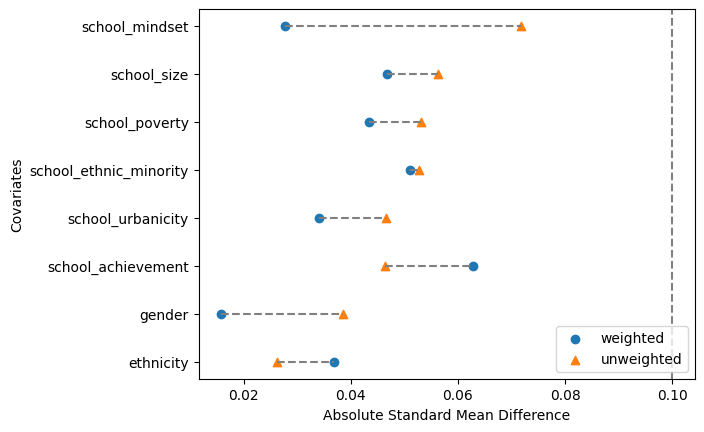

In [18]:
res = evaluate(weight_model, X, T, Y, cv="auto")
res.plot_covariate_balance(kind="love", phase="valid", thresh=0.1)

Weighted이후에 |SMD|가 더 줄어든 것을 보았을 때, Weighted 이후 밸런스가 개선되었음을 확인할 수 있습니다.    
|SMD| < 0.1 이 목표

### Propensity Score Overlap
아래는 처음에 Logistic Regression으로 추정한 Propensity Score의 Distribution을 나타낸 것입니다.

<Axes: title={'center': 'Propensity Distribution'}, xlabel='Propensity', ylabel='Probability density'>

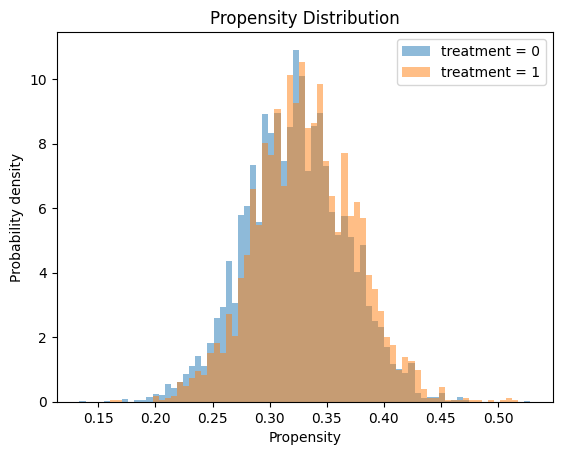

In [19]:
plot_propensity_score_distribution(
    propensity=data_ps['propensity_score'],
    treatment=data_ps['intervention'],
    reflect=False,
    kde=False,
    norm_hist=True,
)

하지만 이는 하나의 데이터에 적합 및 예측을 동시에 하기 때문에 Overlap이 실제보다 좋아보일 수 있습니다.

그렇다면 OOF 폴드 예측으로 얻은 PS 분포를 그려봅시다.   
(cv = None -> 단일 적합, cv = "auto" -> 교차검증)

<Axes: title={'center': 'Propensity Distribution'}, xlabel='Propensity', ylabel='Probability density'>

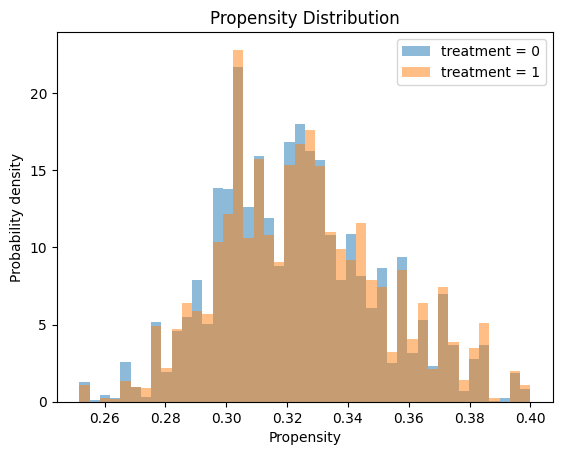

In [20]:
res.plot_weight_distribution(phase="valid", reflect=False, norm_hist=True)

OOF로 검증해도 Propensity Score의 Overlap 및 Positivity가 양호한 것을 확인

### IPW 가중치 분포 및 유효표본수(ESS)

In [21]:
w = weight_model.compute_weights(X, T)
ESS = (w.sum()**2) / (w**2).sum()
N   = len(w)
VIF = N / ESS

print(f"ESS = {ESS:.2f} (N = {N})  ->  VIF = {VIF:.4f}")

ESS = 10354.68 (N = 10391)  ->  VIF = 1.0035


Text(0.5, 1.0, 'IPW weights (log y)')

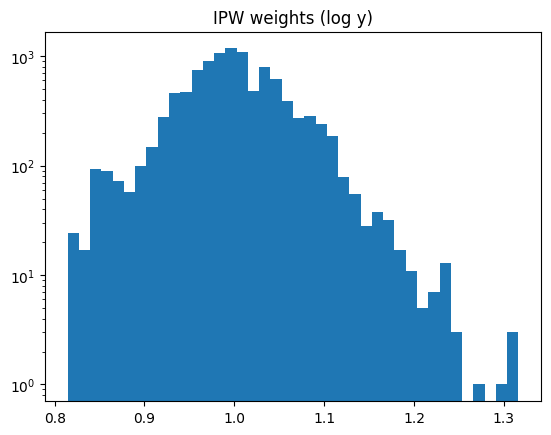

In [22]:
plt.figure(); plt.hist(w, bins=40); plt.yscale('log'); plt.title('IPW weights (log y)')

결과 해석
1) ESS와 N수가 거의 비슷한 것을 확인할 수 있음(VIF ≈ 1) -> 가중치가 고르게 퍼져있다
2) 히스토그램이 1 주변에 모여있고(= 가중치 과도하게 쏠리지 않음), 꼬리 부분도 완만(= 극단 가중치 거의 없음)



다만 VIF와 Propensity Score Overlap이 정량적으로 얼마나 되어야 한다 라는 지표는 찾을 수 없었습니다.    


데이터 및 분석의 맥락에 따라 다르게 지정하되, propensity score의 overlap이 약하다면 위에서 진행한 clipping 등의 방법을 적용해보면 좋습니다. 

[참고자료]
- Yang, Jeff Y., et al. "Propensity score methods to control for confounding in observational cohort studies: a statistical primer and application to endoscopy research." Gastrointestinal endoscopy 90.3 (2019): 360-369.

- Austin, Peter C. "Informing power and sample size calculations when using inverse probability of treatment weighting using the propensity score." Statistics in Medicine 40.27 (2021): 6150-6163.



## **Double/Debiased Machine Learning (비모수 버전의 Regression 처럼 활용 가능)**

코드 및 데이터 참조 출처: https://matheusfacure.github.io/python-causality-handbook/22-Debiased-Orthogonal-Machine-Learning.html

DML은 ATE와 CATE와 같은 인과적 모수를 구하는 하나의 프레임입니다.   

간략하게 소개하자면, DML은 복잡한 보조모형은 머신러닝으로 학습하고, 직교화(Neyman 점수)와 교차적합으로 bias를 상쇄해 ATE·CATE 같은 인과모수를 정규성으로 안정적으로 추정하는 프레임워크입니다.             
이를 통해 인과 매개변수의 추정 절차와 성가신 매개변수의 추정 절차를 분리할 수 있는 Frisch-Waugh-Lovell의 장점을 그대로 지닌 방법입니다.

코드와 함께 더 자세하게 알아보기 위해 계량경제학에서 자주 사용하는 데이터셋 중 하나인 **아이스크림 판매 데이터셋**을 활용해보겠습니다.  


In [23]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_predict
import seaborn as sns

In [24]:
test = pd.read_csv("../data/matheus_data/ice_cream_sales_rnd.csv")
train = pd.read_csv("../data/matheus_data/ice_cream_sales.csv")
train.head()

,temp,weekday,cost,price,sales
0,17.3,6,1.5,5.6,173
1,25.4,3,0.3,4.9,196
2,23.3,5,1.5,7.6,207
3,26.9,1,0.3,5.3,241
4,20.2,1,1.0,7.2,227


### **Frisch-Waugh-Lovell 응용 DML**

In [25]:
y = "sales"
T = "price"
X = ["temp", "weekday", "cost"]

debias_m = LGBMRegressor(max_depth=3, verbosity=-1)
denoise_m = LGBMRegressor(max_depth=3, verbosity=-1)

train_pred = train.assign(price_res =  train[T] - cross_val_predict(debias_m, train[X], train[T], cv=5),
                          sales_res =  train[y] - cross_val_predict(denoise_m, train[X], train[y], cv=5))

위의 코드는 FWL(Frisch-Waugh-Lovell) 정리($Y_i - \mathbb{E}[Y_i\mid X_i] = \tau\,(T_i - \mathbb{E}[T_i\mid X_i]) + \varepsilon$)에서 $ \mathbb{E}[Y_i\mid X_i] $ 와 $\mathbb{E}[T_i\mid X_i] $를 머신러닝을 사용하여 추정합니다.    

이를 통해 Y와 T의 잔차를 추정할 때 교호작용(변수 간의 Interaction)과 비선형성을 모델링할 수 있고, 동시에 FWL 스타일의 직교화를 유지할 수 있게끔 합니다.     

그렇다면 변수명을 debias_m, 그리고 denoise_m이라고 지정한 이유는 무엇일까요?    

- **debias_m**  
  : FWL 정리의 식에서 $T - M_t( = \tilde{T})$부분으로, X의 모든 교란 편향이 모델에 의해 제거된 부분입니다.($M_t := \mathbb{E}[T_i\mid X_i]$를 머신러닝으로 추정한 모델)          
  즉, $\tilde{T}$는 X에 직교하는, X로 인한 bias를 없앤 값입니다.    

- **denoise_m**  
  :FWL 식에서 $Y - M_y(= \tilde{Y})$부분으로, Y에서 분산을 제거하는 부분입니다.($M_y := \mathbb{E}[Y_i\mid X_i]$를 머신러닝으로 추정한 모델)            
  즉, $\tilde{Y}$는 X로 인한 모든 분산이 제거된 값입니다.

또한 debias_m과 denoise_m값을 추정할 때 K-Fold 방식을 사용하여 머신러닝의 고질적인 과적합 문제를 방지합니다.

위에서 구한 모델을 활용하여 최종 ATE를 구해봅시다.

In [26]:
import statsmodels.formula.api as smf

final_model = smf.ols(formula='sales_res ~ price_res', data=train_pred).fit()
final_model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.0106,0.072,0.148,0.883,-0.131,0.152
price_res,-3.9228,0.071,-54.962,0.000,-4.063,-3.783


지금 구한 코드는 DML의 debias_m, denoise_m을 반영해서 sales와 price간의 음의 인과관계(가격이 오르면 sales가 떨어진다)를 잘 구한 모습입니다.    

하지만 debias_m, denoise_m을 반영하지 않고, 즉 다른 교란변수(X)의 영향을 제어하지 않고 OLS를 돌리면 어떻게 될까요?

In [27]:
final_model = smf.ols(formula='sales ~ price', data=train_pred).fit()
final_model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,192.9679,1.013,190.414,0.000,190.981,194.954
price,1.2294,0.162,7.575,0.000,0.911,1.547


이렇듯 **가격이 오르면 sales가 오른다는 이상한 인과관계**를 추정하게 됩니다.       

여기서 볼 수 있듯이 인과관계 추정을 위해서는 교란변수를 잘 컨트롤하는 것이 중요합니다.

지금까지 DML을 활용해서 ATE를 구해보았습니다.     
    
그렇다면 DML을 활용해서 CATE를 구하는 방법은 무엇일까요?

### **DML 응용 CATE 계산**

CATE를 구하기 위해서는 ATE와 동일한 식을 사용하지만, 거기에 T잔차와 다른 공변량과의 상호작용($\pmb{\beta}_2 \pmb{X_i} \tilde{T_i}$)텀을 추가하도록 할 것입니다.        

즉, $\tilde{Y_i} = \alpha + \beta_1 \tilde{T_i} + \pmb{\beta}_2 \pmb{X_i} \tilde{T_i} + \epsilon_i$라는 식을 추정한다면 CATE 값을 얻을 수 있습니다.

In [28]:
final_model_cate = smf.ols(formula='sales_res ~ price_res * (temp + C(weekday) + cost)', data=train_pred).fit()

cate_test = test.assign(cate=final_model_cate.predict(test.assign(price_res=1))
                        - final_model_cate.predict(test.assign(price_res=0)))

price_res * (temp + C(weekday) + cost)라는 T와 다른 공변량 간의 상호작용 텀을 넣어 CATE를 추정할 수 있도록 구성했습니다.

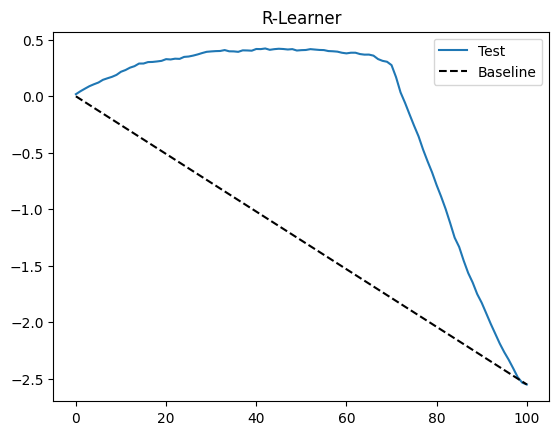

In [29]:
def elast(data, y, t):
    return (np.sum((data[t] - data[t].mean())*(data[y] - data[y].mean())) /
            np.sum((data[t] - data[t].mean())**2))

def cumulative_gain(dataset, prediction, y, t, min_periods=30, steps=100):
    size = dataset.shape[0]
    ordered_df = dataset.sort_values(prediction, ascending=False).reset_index(drop=True)
    n_rows = list(range(min_periods, size, size // steps)) + [size]
    return np.array([elast(ordered_df.head(rows), y, t) * (rows/size) for rows in n_rows])

gain_curve_test = cumulative_gain(cate_test, "cate", y=y, t=T)
plt.plot(gain_curve_test, color="C0", label="Test")
plt.plot([0, 100], [0, elast(test, y, T)], linestyle="--", color="black", label="Baseline")
plt.legend();
plt.title("R-Learner");

위의 곡선에서 볼 수 있듯이 최종 선형 모델을 사용한 DML 절차는 훌륭한 성능을 나타냅니다.

참고로, DML을 활용하여 CATE를 구하는 방법이 R-Learner라고 불리는 메타 학습자의 하나의 종류입니다.

### **Non Parametric Double/Debiased ML**

하지만 위에서 우리는 중간에 머신러닝을 사용하긴 했지만, 최종 ATE/CATE를 구할 때는 OLS, 즉 선형 모델을 사용한 것을 볼 수 있습니다.     
결국 우리는 아직 Y와 T간의 비선형성을 잡을 수 없는 한계가 있었습니다.    

우리는 위에서 추정한 식의 변형을 통해 비선형성까지 머신러닝이 학습할 수 있게 코드를 짤 수 있습니다.    
식의 변형에 대해서는 다음의 링크를 참고해주세요. https://matheusfacure.github.io/python-causality-handbook/22-Debiased-Orthogonal-Machine-Learning.html 

우리는 코드를 통해 Y와 T간의 비선형성을 잡을 수 있는 방법에 대해 알아보겠습니다.   
식의 변형은 다소 복잡할 수 있지만, 코드로 구현하면 간단합니다. 

In [30]:
model_final= LGBMRegressor(max_depth=3)

# create the weights
w= train_pred["price_res"]** 2

# create the transformed target
y_star= (train_pred["sales_res"]/ train_pred["price_res"])

# use a weighted regression ML model to predict the target with the weights.
model_final.fit(X=train[X], y=y_star, sample_weight=w);

위의 기계학습 모델은 기존의 식을 변형해 가중치 w($\tilde{T}_i^2$)와 y_star($\frac{\tilde{Y}_i}{\tilde{T}_i}$) 텀을 추가해서    
X값을 Y값에 학습시키기만 해도 Y와 T의 비선형성을 포함하는 최종 CATE 값을 구할 수 있다는 장점이 있습니다.

이제 테스트 데이터셋을 사용하여 이 비모수적 버전을 이전에 사용한 선형 버전과 비교해 보겠습니다.        

먼저 개별 처치 효과를 추정합니다.

In [31]:
cate_test_non_param = test.assign(cate=model_final.predict(test[X]))

다음으로, 비모수 누적 탄성 곡선을 모수(선형) 버전의 이중/직교 기계학습에서 얻은 곡선과 나란히 플롯을 그릴 수 있습니다.

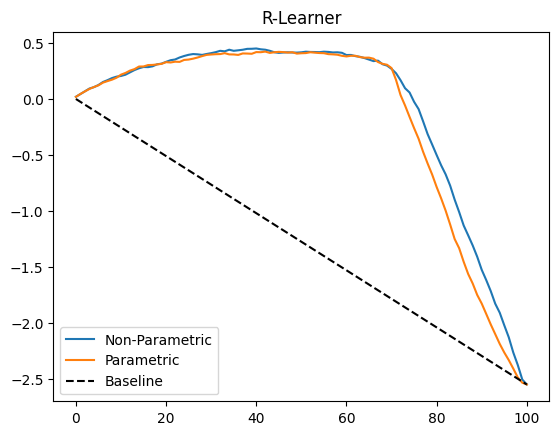

In [32]:
gain_curve_test_non_param = cumulative_gain(cate_test_non_param, "cate", y=y, t=T)
plt.plot(gain_curve_test_non_param, color="C0", label="Non-Parametric")
plt.plot(gain_curve_test, color="C1", label="Parametric")
plt.plot([0, 100], [0, elast(test, y, T)], linestyle="--", color="black", label="Baseline")
plt.legend();
plt.title("R-Learner");

### Caution!

하지만 Non-Parametric으로 결과를 구할 경우 해석에 주의할 점이 있습니다.

Non-Parametric은 최종 CATE에서도 비선형 관계를 잡아낼 수 있다는 장점이 있지만, **국소 선형 근사치**만을 찾는 것이기 때문에 

해당 처치 수준 또는 처치 주변에서만 그 결과를 해석해야하고, 그 범위를 벗어났을 때에는 우리가 구한 결과값이 다르게 해석되어야 합니다.    



즉, T가 0일 때의 $\tau(X_i)$값과 T가 60일 때의 $\tau(X_i)$값은 다르게 추정되므로, T가 0일 때의 $\tau(X_i)$값으로 T가 60일 때에도 그대로 적용해서 해석을 하면 안됩니다.

그럼 아래에서는 더욱 다양한 DML 응용 방법 및 모델을 알아보도록 하겠습니다.

### **DML 모델(1) Partially linear models (PLM)**

PLM의 기본 아이디어는 처치 효과는 선형(상수 계수 θ) 로 두고, 공변량 효과는 비모수/머신러닝 $g_0(X)$로 흡수해버리는 것입니다.     
위에서 FWL개념에서 언급한 것과 동일하게 고차원의 X를 ML로 유연하게 처리하면서도 $θ_0$에 대해 표준 오류 및 신뢰구간을 잘 뽑아낼 수 있습니다.

이 방법은 처치가 연속적이거나(Ex. 가격, 광고비, 용량 등) 처치가 이진이더라도 ATE만 알고 싶을 때 사용하기 좋습니다.

PLM은 크게 두 종류로 나눌 수 있습니다.     
Instrumental Variable 설정 여부에 따라 Partially Linear Regressor(PLR)과 Partially Linear IV Regressor(PLIV)로 나눠서 각각의 코드를 살펴보도록 하겠습니다.

#### **(1) Partially Linear Regressor(PLR)**

PLR은 위에서 FWL개념을 DML에 적용시키면서 했던 방법이랑 거의 동일한 Flow로 흘러갑니다.    
수식으로 정리하자면 아래와 같습니다.

$Y=θ_0D​+g_0​(X)+ζ$,  $E[ζ|X, D] = 0$  
$D = m_0(X) + V$,   $E[V|X] = 0$

- $θ_0$: ATE(처치가 이진일 때)           
         (처치가 연속일 때는 Average Partial Effect)
- $g_0(X)$ = E[Y|D = d, X = x]: Y의 X로 인한 부분(denoise_m에 해당) -> 임의의 비선형 함수(고차원/ML로 추정)
- $m_0(X)$ = E[D|X]를 학습: D의 X로 인한 부분(debias_m에 해당)
- $V$:=D − $m_0$​(X) ⇒ E[V∣X]=0
- $ζ$: Error term

Partially Linear Regressor라고 불리는 이유는 위의 파트에서 설명했듯이 denoise, debias부분은 비선형 모델로 추정하지만, 최종적으로 ATE를 추정할 때는 선형 회귀를 돌리는, 말 그대로 모델 프로세스 중 $θ_0$을 구할 때만 부분적으로 선형을 쓰기 때문입니다.    

다만 위에서는 모든 과정을 수작업으로 했지만, 이번에는 doubleML에서 제공하는 모듈을 써서 같은 과정을 진행하고, 몇몇 유용한 옵션(Ex. n_folds, n_rep)을 사용해서 결과를 비교해보도록 하겠습니다.

In [33]:
import doubleml as dml
from doubleml.datasets import fetch_401K
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, LogisticRegressionCV

DoubleML 사이트(https://docs.doubleml.org/stable/guide/models.html#partially-linear-models-plm) 에 나와있는 데이터를 사용해 코드를 짜보도록 하겠습니다.

In [34]:
data = fetch_401K(return_type='DataFrame')
features = ['age','inc','educ','fsize','marr','twoearn','db','pira','hown']
data.head()

,nifa,net_tfa,tw,age,inc,fsize,educ,db,marr,twoearn,e401,p401,pira,hown
0,0.0,0.0,4500.0,47,6765.0,2,8,0,0,0,0,0,0,1
1,6215.0,1015.0,22390.0,36,28452.0,1,16,0,0,0,0,0,0,1
2,0.0,-2000.0,-2000.0,37,3300.0,6,12,1,0,0,0,0,0,0
3,15000.0,15000.0,155000.0,58,52590.0,2,16,0,1,1,0,0,0,1
4,0.0,0.0,58000.0,32,21804.0,1,11,0,0,0,0,0,0,1


In [35]:
dml_data = dml.DoubleMLData(data, y_col='net_tfa', d_cols='e401', x_cols=features)

- Y: net_tfa(순자산)         
- d_cols: e401(퇴직연금 적격성)        
- Features: [age: '나이',inc: '소득',educ: '교육',fsize: '가구원 수',marr: '결혼여부',twoearn: '맞벌이 가구 여부',db: '확정급여형(Defined Benefit) 연금 보유 여부',pira: 'IRA(개인퇴직계좌) 보유 여부)',hown: '주택 보유 여부']

In [36]:
ml_g = make_pipeline(StandardScaler(), LassoCV(cv=5, max_iter=10000))
ml_m = make_pipeline(StandardScaler(),
                     LogisticRegressionCV(cv=5, penalty='l1', solver='liblinear', max_iter=1000, random_state=42))

- **ml_g**: $g_0(X)$의 추정치 $\hat{g_0}(X)$      
  -> StandardScaler: Lasso의 L1규제가 변수 스케일에 민감하므로 표준화를 통해 공정하게 패널티 부여        
  -> LassoCV: 많은/상관된 X에서도 변수선택 + 규제로 과적합을 줄이며 5-fold CV로 𝜆를 자동 선택
     
- **ml_m**: $m_0(X)$의 추정치 $\hat{m}(X)$
  -> 여기서 D는 이진이므로 $m_0(X)$ = E[D|X] = P(D = 1|X)      
  -> L1 Logistic CV: P(D = 1|X)를 추정하기 위해 Logistic 사용         

In [37]:
kf = KFold(n_splits=5, shuffle=True, random_state=123)
folds = list(kf.split(data[features], data['net_tfa']))

In [38]:
dml_plr = dml.DoubleMLPLR(dml_data, ml_l=ml_g, ml_m=ml_m, n_folds=5, n_rep=10)
dml_plr.fit()
dml_plr.summary

,coef,std err,t,P>|t|,2.5 %,97.5 %
e401,6153.26481,1456.595739,4.224415,0.000024,3290.780153,9008.140014


머신러닝의 고질적인 과적합 문제를 해결하기 위해 n_folds = 5로 OOF를 진행해서 최종 ATE를 구하고, n_rep = 10으로 이 과정을 10번 반복하여 좀 더 강건한 추정을 가능하도록 합니다.         

참고로 위의 FWL 응용 DML방식에서 사용한 수작업 코드로 구한 결과와 비교해도 ATE값이 크게 다르지 않게 나오는 것을 확인할 수 있습니다. (95% CI에 겹침/아래의 코드 결과 참고)

In [39]:
from sklearn.base import clone
import statsmodels.formula.api as smf

y, d = 'net_tfa', 'e401'

def oof_predict(pipe, Xdf, ysr, folds, proba=False):
    """Same-fold OOF 예측 (각 폴드에서 clone 해서 학습/예측)."""
    oof = np.empty(len(ysr))
    for tr, te in folds:
        p = clone(pipe)
        p.fit(Xdf.iloc[tr], ysr.iloc[tr])
        oof[te] = (p.predict_proba(Xdf.iloc[te])[:, 1] if proba else p.predict(Xdf.iloc[te]))
    return oof

# OOF 예측: g_hat(X)=E[Y|X], m_hat(X)=P(D=1|X)
g_hat_oof = oof_predict(ml_g, data[features], data[y], folds, proba=False)   # DoubleML 모듈 적용 시 사용한 LassoCV 파이프라인
m_hat_oof = oof_predict(ml_m, data[features], data[d], folds, proba=True)    # DoubleML 모듈 적용 시 사용한 LogisticCV 파이프라인


# 잔차 컬럼 만들고 OLS
train_pred = data.assign(
    **{f"{d}_res": data[d] - m_hat_oof,
       f"{y}_res": data[y] - g_hat_oof}
)

final_model = smf.ols(formula=f'{y}_res ~ {d}_res', data=train_pred).fit()
print("=== Residual OLS (ATE) ===")
print(final_model.summary().tables[1])

# DoubleML과 차이 확인
print("Diff (Resid OLS - DoubleML):", final_model.params[f'{d}_res'] - dml_plr.coef[0])

=== Residual OLS (ATE) ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    106.2167    563.412      0.189      0.850    -998.186    1210.620
e401_res    5863.0088   1252.451      4.681      0.000    3407.949    8318.068
Diff (Resid OLS - DoubleML): -290.25603008296275


즉, 좀 더 간단하고 더 많은 모델 옵션을 제공하는 DoubleML의 모듈 코드를 사용해도 상관없으므로 편하신 방법을 선택하시면 됩니다.

#### **Sensitivity Analysis**

구한 결과값이 실제로 인과추론의 중요한 가정 중 하나인 Unconfoundedness가정이 깨졌을 때 결과가 얼마나 흔들리는지 Sensitivity Analysis를 통해 체크해보도록 하겠습니다.

Sensitivity Analysis는 숨은 U가 D와 Y에 미치는 영향의 강도를 가정하고 그 때 효과 추정치, p값, 신뢰구간이 어떻게 변하는지를 확인합니다.     

이 절차는 Unconfoundedness가 성립함을 증명하는 도구가 아니라, 가정 위반이 어느 정도까지는 결론이 유지되는지(혹은 붕괴되는지) 를 정량화하는 강건성 점검입니다.

코드를 보면서 결과를 확인해보겠습니다.      
 U의 존재를 가정하고, 해당하는 U가 Y와 D에 얼마나 영향을 미치는지를 먼저 정해보겠습니다.     

1. **cf_y, cf_d옵션**을 통해 U가 Y와 D에 미치는 최대 영향을 디폴트값인 0.03으로 설정합니다.
2. **rho 옵션**을 통해 U가 Y와 D에 미치는 영향의 상관을 1로 설정해 추정치 편향을 최대로 키워 마찬가지로 보수적으로 설정합니다.
3. **level**은 신뢰구간으로, 95%의 신뢰구간으로 측정하고, **null_hypothesis**를 0으로 설정해 U라는 교란이 있어도 $\theta$가 0이 아닌, 즉 ATE가 0이 아니고 유의미한 값을 가지냐를 확인해봅니다.

In [40]:
sens_weak = dml_plr.sensitivity_analysis(
    cf_y=0.03,
    cf_d=0.03,
    rho=1.0,
    level=0.95,
    null_hypothesis=0.0
)

df = pd.json_normalize(dml_plr.sensitivity_params if isinstance(dml_plr.sensitivity_params, list)
                       else [dml_plr.sensitivity_params])
df[['theta.lower', 'theta.upper']]

,theta.lower,theta.upper
0,[2376.9511504348816],[9928.863081535445]


Y와 D에 각각 3%만큼 영향을 미치는 U가 있다고 가정했을 때, 조정된 $\theta$값은 95% 신뢰구간 내에서 [2349.26, 9908.22]로 여전히 0이 아닌 양의 값을 가지는 것을 확인할 수 있습니다.       

즉, $H_0: \theta = 0$은 여전히 기각되어 우리가 가정한정도로 영향을 미치는 Confounder가 있을 때에도 여전히 ATE는 유의하게 나온다는 것을 확인할 수 있고, 이 정도의 가정 위반에도 여전히 우리가 구한 ATE값이 유의하다는 것을 확인할 수 있습니다.

Sensitivity Analysis 내용은 이것으로 마치고, 마지막으로 PLR 방법에서의 조금 더 다양한 옵션을 살펴보도록 하겠습니다.

* PLR 결과를 바탕으로 Bootstrap

아래 코드를 통해 부트스트랩을 수행해 추정치의 불확실성(표준오차·신뢰구간) 을 더 견고하게 평가할 수 있습니다.

In [41]:
dml_plr.bootstrap(method='normal', n_rep_boot=1000)

dml_plr.summary

,coef,std err,t,P>|t|,2.5 %,97.5 %
e401,6153.26481,1456.595739,4.224415,0.000024,3290.780153,9008.140014


* **CATE 추정**

In [42]:
#CATE추정 시 n_rep는 1을 초과하면 안되기 때문에 n_rep로 다시 fit
dml_plr_cate = dml.DoubleMLPLR(dml_data, ml_l=ml_g, ml_m=ml_m, n_folds=5, n_rep=1)
dml_plr_cate.fit()

# 소득별 basis 만들기
n = len(data)

B = pd.DataFrame(
    {"const": np.ones(n),
     "inc": data["inc"].values,
     "inc_sq": data["inc"].values ** 2,
    },
    index=data.index,
)

blp = dml_plr_cate.cate(B)

위의 코드는 아래의 수식을 나타내기 위해 B(basis)를 설정했습니다.    
$\hat{\tau}(x) = \hat{\beta_0} + \hat{\beta_1} * inc + \hat{\beta_2} * inc^2$    

즉, 처치(퇴직연금 적격성 여부)가 Y(순자산)에 미치는 효과가 소득(inc)에 따라 어떻게 달라지는지를 보기 위한 새로운 식을 만들어보았습니다.

In [43]:
beta = blp.blp_model.params      
se   = blp.blp_model.bse         
beta

const    -39155.063330
inc           2.000642
inc_sq       -0.000016
dtype: float64

베타값의 결과는 위와 같고, 순서대로 $\hat{\beta_0}$, $\hat{\beta_1}$, $\hat{\beta_2}$값입니다.    

임의로 만든 basis에 따른 CATE값일 뿐이므로 결과 자체의 해석에 신경쓰기보다는 DML을 사용해서 선형으로 CATE를 구할 때 어떻게 코드가 구성되는지만 참고해주시면 됩니다.

#### **(2) Partially Linear IV Regressor(PLIV)**

PLIV는 도구변수(IV)를 사용해야할 때, 즉 처치(관심)변수 D가 외생이 아닌 내생이라 X만으로는 인과추론의 가정이 성립하지 않을 때 사용할 수 있는 방법입니다.

- $Y−θ_0D​=g_0​(X)+ζ$,
- $E[ζ∣Z,X]=0$;
- $Z=m_0​(X)+V$,
- $E[V∣X]=0$

다른 변수들은 PLM과 같은 변수지만, **PLIV에서는 Z라는 도구변수가 추가**됩니다.    

PLR에서 사용한 데이터셋을 그대로 사용해서 PLIV의 코드를 살펴보도록 하겠습니다.     

- Y와 X는 PLR과 똑같은 변수 사용
- D: e401(적격성)이 아닌 p401(퇴직연금 가입 여부) 변수 사용
- Z: PLR에서의 D 변수였던 e401(퇴직연금 적격 여부)    
즉, 퇴직연금 적격 여부(Z)는 처치변수인 퇴직연금 가입 여부 변수를 통해서만 Y에 영향을 미친다는 가정으로 모델을 돌려보겠습니다.      

이게 적절한 도구변수값인지에 대한 토론보다는 PLIV가 어떻게 코드로 돌아가는지에 집중하는 것이 이번 챕터의 목적이니, 코드부터 살펴보도록 하겠습니다.

변수 세팅은 위에서 말한 것과 동일하게 세팅하겠습니다.

In [44]:
dml_data_pliv = dml.DoubleMLData(
    data,
    y_col='net_tfa',
    d_cols='p401',
    x_cols=features,
    z_cols='e401'         
)

PLR에서 정의한 ml_g, ml_m은 동일하게 사용하도록 하겠습니다.    

다만 PLIV에서는 ml_r 변수로 E[Z|X]값을 추정하는 파이프라인을 새로 추가해야 합니다. (옵션은 나머지 누이선스 변수와 동일)     
ml_r 또한 다른 누이선스 변수와 마찬가지로, X로 예측 가능한 Z의 부분을 걷어낸 잔차를 구하기 위한 변수입니다.

In [45]:
ml_r = make_pipeline(
    StandardScaler(),
    LogisticRegressionCV(cv=5, penalty='l1', solver='liblinear', max_iter=1000, random_state=42)
)

dml_pliv = dml.DoubleMLPLIV(
    dml_data_pliv,
    ml_l=ml_g,        
    ml_m=ml_m,        
    ml_r=ml_r,      
    n_folds=5,
    n_rep=10,
)

그 외의 다른 옵션은 동일하게 세팅하고 모델을 돌려보면 DML 개념을 적용하여 IV를 사용한 결과를 얻을 수 있습니다. 

In [46]:
dml_pliv.fit()
dml_pliv.summary

,coef,std err,t,P>|t|,2.5 %,97.5 %
p401,7244.156987,1943.478712,3.727418,0.000193,3435.008707,11053.305267


### **DML 모델(2) Interactive Regression Models (IRM)**

Interactive Regression Models는 PLM에서 가정하는 homogeneous treatment effect에서 벗어나 모든 사람에게 treatment의 effect가 다를 수 있는, heterogeneous treatment effect 상황에서도 사용할 수 있다는 장점이 있습니다.        

먼저 Treatment가 Binary일 때 사용할 수 있는 Binary IRM에 대해 살펴보도록 하겠습니다.

#### **(1) Binary Interactive Regression Models(IRM)**




IRM Model의 Form은 다음과 같습니다.        

- $Y = g_0(D, X) + U$,    $E[U | X, D] = 0$
- $D = m_0(X) + V$,    $E[V | X] = 0$

앞서 말했듯이 Treatment는 $D \in \lbrace 0,1 \rbrace$인 이진 변수이고,        

모델의 타겟 변수인 ATE는 다음과 같이 나타낼 수 있습니다.      
$\theta_0 = \mathbb{E}[g_0(1, X) - g_0(0,X)]$,  $g_0 = E[Y | D = d, X]$    

Averate Treatment Effect of the Treated(ATTE)는 다음과 같습니다.    
$\theta_0 = \mathbb{E}[g_0(1, X) - g_0(0,X) | D=1]$    

PLM에서 사용했던 데이터셋을 사용한 다음의 코드를 보면서 IRM이 어떻게 ATE를 추정하는지 살펴보도록 하겠습니다.

In [47]:
from doubleml import DoubleMLData
from doubleml.irm import DoubleMLIRM

dml_data_irm = DoubleMLData(
    data,
    y_col='net_tfa',     # Y: 순자산
    d_cols='p401',       # D: 퇴직연금 가입 여부 (이진)
    x_cols=features      # X: 기존 사용하던 공변량
)

ml_g나 ml_m은 기존에 정의했던 변수 그대로 사용해 비선형성을 포착하고, 나머지 옵션(n_folds, n_rep)도 동일하게 사용하도록 하겠습니다.

trimming 옵션은 IRM에서 AIPW/orthogonal Score를 사용하기 때문에 Porpensity Score의 안정화를 위한 옵션입니다.       
Propensity Score가 IRM에서 어떻게 활용되는지는 밑에서 더 자세히 설명하도록 하겠습니다.

In [48]:
irm_ate = DoubleMLIRM(
    dml_data_irm,
    ml_g=ml_g,              
    ml_m=ml_m,              
    n_folds=5,              
    n_rep=10,               
    score='ATE',            
    trimming_rule='truncate',
    trimming_threshold=0.01
)

In [49]:
irm_ate.fit()
irm_ate.summary

,coef,std err,t,P>|t|,2.5 %,97.5 %
p401,6819.42133,2792.335665,2.442193,0.014598,1379.789373,12292.301454


ATE가 아닌 ATTE를 추정하고 싶다면 score옵션만 ATE에서 ATTE로 바꾸면 됩니다.

In [50]:
irm_atte = DoubleMLIRM(
    dml_data_irm,
    ml_g=ml_g,              
    ml_m=ml_m,              
    n_folds=5,              
    n_rep=10,               
    score='ATTE',            
    trimming_rule='truncate',
    trimming_threshold=0.01 
)

In [51]:
irm_atte.fit()
irm_atte.summary

,coef,std err,t,P>|t|,2.5 %,97.5 %
p401,1571.255518,9298.593587,0.168978,0.865814,-16699.161017,19796.164056


#### **(2) Average Potential Outcomes(APOs)**

Binary IRM 코드에서는 Treatment가 binary일 때의 경우를 살펴보았습니다.    

하지만 Treatment가 일반적인 이산값($D \in \lbrace d_0, \dots, d_l \rbrace$)일 때는 식이 다음과 같이 일반화 될 수 있습니다.

$\begin{align}\begin{aligned}Y = g_0(D, X) + U, & &\mathbb{E}(U | X, D) = 0,\\A_j = m_{0,j}(X) + V, & &\mathbb{E}(V | X) = 0,\end{aligned}\end{align}$

- $A_j := 1\lbrace D = d_j\rbrace$: j번째 처리레벨을 실제로 받았는지
- $g_0(D,X) = E[Y|D = d, X = x]$       
- $m_{0,j}(X) = P(D = d_j | X)$: j번째 레벨의 **Propensity Score**
- $U, V$: 잔차

또한 타겟 파라미터 $\theta$는 다음과 같이 정의됩니다.       
$\theta_{0,j} = \mathbb{E}[g_0(d_j, X)]$   

즉, 각 처리레벨 $d_j$에 대한 $E[Y(d_j)]$를 구하는 과정입니다. 코드 구현은 treatment_level로 한 번에 하나의 처리레벨에 대한 APO를 구합니다.


APO 추정 과정을 개략적으로 살펴보면 각 개인에 대해, AIPW/orthogonal score 형태의 pseudo-outcome을 만든 다음, 그걸 전체 평균내서 $\theta_{0,j}$ 즉 APO를 추정합니다.

먼저 예시로 사용할 데이터셋을 불러오겠습니다.

In [52]:
from doubleml.datasets import make_irm_data
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

np.random.seed(3333)
df = make_irm_data(
    theta=0.5,
    n_obs=500,
    dim_x=10,
    return_type='DataFrame'
)

In [53]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,y,d
0,-0.368577,-0.688886,0.793315,-0.934066,-1.015731,-1.630031,-1.474996,-0.477593,-0.676716,0.552010,-1.063518,0.0
1,0.078426,-1.028731,0.755885,-0.223044,-0.311049,-0.059540,-0.123388,-0.508408,-0.094020,0.292126,-0.327716,1.0
2,-2.899021,-1.294123,-0.884821,0.421903,-0.290983,-0.740970,-2.104354,-0.020588,0.710170,0.135842,-0.150180,0.0
3,0.502005,0.902920,-0.158726,0.529506,0.012832,0.987503,-0.935100,0.523039,0.016426,0.363400,0.529042,1.0
4,-1.843018,0.170705,0.712846,0.118400,-0.128942,0.128420,0.333902,-1.666221,-0.455829,1.606466,-0.154075,0.0


**APO(d=0) 추정**

처리레벨 $d_0$일 때의 APO를 구해보겠습니다.   

먼저 DobleMLData 클래스 객체를 생성하여 DoubleML을 적용할 데이터와 그 안에서 데이터 내의 결과변수(y_col), 처리변수(d_cols)에 해당하는 컬럼명을 지정합니다.       

또한 여전히 DML을 사용하기 때문에 Nuisance Learner를 설정해줍니다.     
PLM에서는 선형 모형(Lasso, LogisticRegression)을 사용했지만, 이번에는 조금 다르게 비선형 모델인 RandomForest를 사용해서 코드를 돌려보도록 하겠습니다.

In [54]:
# DoubleMLData 생성
dml_data = dml.DoubleMLData(
    df,
    y_col='y',
    d_cols='d'
)

# nuisance learner 설정
ml_g = RandomForestRegressor(
    n_estimators=100,
    max_features=10,
    max_depth=5,
    min_samples_leaf=2,
    random_state=42
)

ml_m = RandomForestClassifier(
    n_estimators=100,
    max_features=10,
    max_depth=5,
    min_samples_leaf=2,
    random_state=42
)

그 다음 DoubleMLAPO 클래스를 사용하여 데이터 내의 처리 레벨($d_j$) 각각에 대한 APO를 추정합니다.     

이 때, 데이터상에 기재되어있는 d_cols의 값에 따라서 treatment_level값을 바꿔주면서 돌리면 됩니다.     
예시로 사용하는 데이터(make_irm_data)는 아래의 코드에서 볼 수 있듯이 d값이 0과 1뿐이라 treatment_level을 0과 1로 설정해 APO를 구해보도록 하겠습니다.   

In [55]:
df['d'].value_counts()

d
1.0    258
0.0    242
Name: count, dtype: int64

만약 데이터 상에 더 많은 이산값이 존재한다면 treatment_level값을 해당 값에 맞게 설정해서 코드를 실행하면 됩니다.

In [56]:
# APO: d = 0일 때 E[Y(0)] 추정
apo_d0 = dml.irm.DoubleMLAPO(
    obj_dml_data=dml_data,
    ml_g=ml_g,
    ml_m=ml_m,
    treatment_level=0,      # APO(d=0)
    n_folds=5,              # 기본 cross-fitting folds
    n_rep=3,                # sample split 반복 → 더 안정적
    normalize_ipw=True,     # IPW weight 정규화 (variance 안정화)
    trimming_rule='truncate',
    trimming_threshold=0.01 # PS가 0/1 너무 근처면 잘라냄(truncate)
)

apo_d0.fit()

apo_d0.summary

,coef,std err,t,P>|t|,2.5 %,97.5 %
d,-0.097186,0.128415,-0.756813,0.449162,-0.363625,0.154502


**d=1에 대한 APO**   

d = 1일 때의 APO는 treatment_level 옵션을 1로 맞춰주면 됩니다.

In [57]:
apo_d1 = dml.irm.DoubleMLAPO(
    obj_dml_data=dml_data,
    ml_g=ml_g,
    ml_m=ml_m,
    treatment_level=1,      # APO(d=1)
    n_folds=5,
    n_rep=3,
    normalize_ipw=True,
    trimming_rule='truncate',
    trimming_threshold=0.01
)

apo_d1.fit()
apo_d1.summary

,coef,std err,t,P>|t|,2.5 %,97.5 %
d,0.567373,0.110446,5.137104,2.790040e-07,0.327588,0.783844


#### **(3) Average Potential Outcomes(APOs) for Multiple Treatment Levels**

위에서 구한 DoubleMLAPO 클래스의 경우 treatment_level을 하나하나 지정해서 돌려서 각각에 대한 APO를 확인하는 데에는 좋지만, 결국 하나하나 지정해서 돌려야 하기 때문에 데이터 상의 treatment_level이 많을 때 사용하기에는 다소 무리가 있습니다.    

이런 경우에는 DoubleMLAPOs라는 클래스를 사용해서 모든 treatment_level에 대한 APO를 한꺼번에 구하고, treatment_level간의 APO의 차이를 볼 수 있습니다.     

즉, 우리의 관심변수 $\theta$는 이제 아래와 같이 정의됩니다.      
$\theta_{0,jk} = \mathbb{E}[g_0(d_j, X) - g_0(d_k, X)]$     

위의 $\theta$값을 구하기 위해 우선 아래의 코드로 모든 treatment_level에 대한 APO를 한꺼번에 구해보겠습니다.

지금까지는 Treatment가 Binary인 데이터셋으로 진행했지만 이번에는 Treatment가 이산형인 데이터셋을 임의로 구성해보도록 하겠습니다.

In [58]:
# 랜덤 시드 고정
np.random.seed(3141)

n_obs = 1000
n_vars = 5
n_treatments = 6  # 0~5까지 총 6개 그룹

# X 변수 생성
X = np.random.normal(size=(n_obs, n_vars))

# Treatment(d) 생성: 0~5
# 변수 개수에 맞춰서 가중치(coeffs) 행렬 크기를 (5, 6)으로 늘려줌
coeffs_d = np.random.normal(size=(n_vars, n_treatments))
logits = np.dot(X, coeffs_d)

# 소프트맥스로 확률 계산해서 그룹 배정
probs = np.exp(logits) / np.sum(np.exp(logits), axis=1, keepdims=True)
d = np.array([np.random.choice(np.arange(n_treatments), p=p) for p in probs])

# y값 생성
# d가 0일 땐 효과 0, 1부터 5까지는 각각 2, 4, 6, 8, 10씩 효과를 줌
y = np.dot(X, np.random.normal(size=n_vars)) + np.random.normal(size=n_obs)

for k in range(1, n_treatments):
    effect = k * 2.0  # 효과 크기 설정 (2.0, 4.0 ... 10.0)
    y += effect * (d == k)

# 데이터프레임 만들기
df = pd.DataFrame(X, columns=[f'X{i+1}' for i in range(n_vars)])
df['d'] = d
df['y'] = y

# DoubleMLData 객체로 변환
data_multi_levels = DoubleMLData(df, y_col='y', d_cols='d')

print(f"Treatment 값: {sorted(df['d'].unique())}")
print(data_multi_levels)

Treatment 값: [0, 1, 2, 3, 4, 5]
================== DoubleMLData Object ==================

------------------ Data summary      ------------------
Outcome variable: y
Treatment variable(s): ['d']
Covariates: ['X1', 'X2', 'X3', 'X4', 'X5']
Instrument variable(s): None
No. Observations: 1000

------------------ DataFrame info    ------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Columns: 7 entries, X1 to y
dtypes: float64(6), int32(1)
memory usage: 50.9 KB



위와 같이 0, 1, 2, 3, 4, 5의 이산형 Treatment를 가진 데이터셋을 구성하고, 이 데이터셋을 활용해 APOs를 구해보도록 하겠습니다.

In [59]:
# APOs for multiple treatment levels
levels = sorted(data_multi_levels.data['d'].unique())

apos_obj = dml.irm.DoubleMLAPOS(
    obj_dml_data=data_multi_levels,
    ml_g=ml_g,                 # nuisance learner는 APO 코드에서 정의한 것과 동일하게 사용
    ml_m=ml_m,
    treatment_levels= levels,  # dataset의 'd'컬럼에 들어가는 모든 값들로 지정
    n_folds=5,
    n_rep=3,
    normalize_ipw=True,
    trimming_rule='truncate',
    trimming_threshold=0.01
)

apos_obj.fit()

apos_obj.summary

,coef,std err,t,P>|t|,2.5 %,97.5 %
0,-0.096938,0.221989,-0.436680,0.662344,-0.631176,0.338152
1,1.942733,0.607498,3.197925,0.000742,0.770503,3.133408
2,3.621766,0.161479,22.428724,0.000000,3.305273,3.938259
3,6.333048,0.177742,35.630484,0.000000,5.964311,6.681417
4,7.657475,0.477569,16.034264,0.000000,6.780418,8.593496
5,10.023506,0.344221,29.119418,0.000000,9.185083,10.698165


이제 특정 treatment_level를 기준(reference_levels)으로 잡아 다른 treatment_level과의 APO 차이를 한눈에 보고싶다면 아래의 코드를 사용하면 됩니다.      

reference_level과 다른 모든 treatment_level의 APO 차이를 한눈에 정리해줍니다.

In [60]:
acc = apos_obj.causal_contrast(reference_levels=[0])
acc.summary

,coef,std err,t,P>|t|,2.5 %,97.5 %
1 vs 0,2.039671,0.631297,3.230921,0.001234,0.802352,3.276991
2 vs 0,3.718704,0.295311,12.592483,0.000000,3.240212,4.297502
3 vs 0,6.417056,0.316191,20.294884,0.000000,5.885531,7.036780
4 vs 0,7.819512,0.509883,15.335906,0.000000,6.820161,8.818864
5 vs 0,10.064773,0.408706,24.625931,0.000000,9.211302,10.865823


### **DML 모델(3) Difference in Differences Models (DID)**

In [61]:
from doubleml.data import DoubleMLData, DoubleMLPanelData
from doubleml import DoubleMLDID, DoubleMLDIDCS
from doubleml.did.datasets import make_did_SZ2020
from sklearn.base import clone

### **1. 패널 데이터에서의 DID**

데이터 생성

In [62]:
# 패널 데이터 생성
temp_obj = make_did_SZ2020(n_obs=500, dgp_type=1, cross_sectional_data=False, return_type = 'DoubleMLPanelData')
df_panel = temp_obj.data

In [63]:
data_panel = DoubleMLPanelData(
    data=df_panel,
    y_col='y',
    d_cols='d',
    t_col='t',
    id_col='id',
    x_cols=['Z1', 'Z2', 'Z3', 'Z4']
)

df = data_panel.data
df = df.sort_values(by = ['id', 't'])

df.head()

,id,y,d,t,Z1,Z2,Z3,Z4
0,0,209.666713,0,0,-0.419341,0.955932,-0.229880,-0.000641
500,0,415.756183,0,1,-0.419341,0.955932,-0.229880,-0.000641
1,1,236.450209,0,0,0.565972,0.271549,-0.765538,1.319506
501,1,473.162695,0,1,0.565972,0.271549,-0.765538,1.319506
2,2,239.026451,0,0,0.865519,0.160916,0.073123,0.139100


- t가 0이면 전, 1이면 후
- d가 1이면 처치군, 0이면 대조군
- Z: Covariates

패널데이터에서 DID를 실행할 때는 시점 내 상관성(autocorrelation) 문제를 해결하기 위해 id별로 클러스터링을 시행한 후에 모델을 실행해야 합니다.     
패널 데이터를 사용할 경우, 위의 데이터 세팅에서 DoubleMLPanelData 클래스에서 y_col, d_cols, t_col, id_col, x_cols를 실제 데이터 프레임에 맞게 지정해주면 DoubleMLDID 클래스가 자동으로 id별로 클러스터링을 진행해서 DID 결과를 뽑아내줍니다.    

**DID 실행**

In [64]:
# 모델 실행: DoubleMLDID (패널용)
dml_did = DoubleMLDID(
    obj_dml_data=data_panel,
    ml_g=ml_g,               # nuisance learner는 APO 코드에서 정의한 것과 동일하게 사용
    ml_m=ml_m,               # nuisance learner는 APO 코드에서 정의한 것과 동일하게 사용
    n_folds=5, 
    score='observational',
    in_sample_normalization=True
)

dml_did.fit()
dml_did.summary

,coef,std err,t,P>|t|,2.5 %,97.5 %
d,200.595529,8.248578,24.3188,1.240264e-130,184.428613,216.762446


위의 결과는 id_col로 지정한 각 id별로 클러스터링을 진행해 autocorrelation으로 인한 결과값의 과대계상 문제를 최소화합니다.    

**score 파라미터**: DML에서 데이터 편향을 제거하기 위해 사용하는 Neyman Orthogonal Score(스코어 함수)의 형태를 지정     
- **Observational**: 다루는 데이터가 관측 데이터임을 의미. 즉, 처치 집단과 통제 집단이 무작위로 배정된 것이 아니라 특정 공변량에 따라 달라질 수 있다고 가정.        
  따라서, 머신러닝 모델이 추정한 Propensity Score와 Outcome Regression을 모두 활용하여 교란 요인을 통제하는 Doubly Robust(이중 강건) 스코어 함수를 사용
- **Experimental**: 무작위 통제 실험(RCT)나 A/B테스트처럼 처치 확률이 사전에 알려져 있거나 고정된 경우에 사용.         
  이 경우 Propensity Score를 복잡하게 추정할 경우가 없으므로 훨씬 단순해짐.         

**in_sample_normalization 파라미터** :          
Propensity Score가 0이나 1에 너무 가까워서 발생하는 문제를 해결하기 위한 파라미터. 각 교차검증 폴드 내에서 Propensity Score 가중치의 합이 1이 되도록 강제 조정.         
trimming_threshold에서 극단적인 PS값을 강제로 잘라내는 것과는 다르게, in_sample_normalization은 값을 버리지 않고 스케일을 보정해서 전체 균형을 맞추는 방법입니다.

**참고**        
DoubleMLDID 클래스는 기본적으로 Propensity Score 사용이 기본으로 깔려있기 때문에, 시계열 패널 데이터 형식의 경우 T = 0, T = 1의 두 가지 시점별로 시계열 데이터 값들을 평균 등의 값으로 압축시켜서 돌려야 하는 단점이 있습니다.     
즉, T = 0인 기간이 여러 기간에 걸쳐 나타난다고 해도 그 모든 기간을 대표할 수 있는 하나의 통계적인 수치로 요약해서 데이터 상에 나타내야 합니다.        

이 경우 어떤 값으로 나타내냐에 따라 데이터의 시계열적인 특징을 모두 담지 못하는 한계점이 있을 수 있습니다.

### **2. Staggered DID**

Callaway, B., & Sant’Anna, P. H. (2021) 논문에 나오는 Staggered DID 추정 방법 두 가지를 DML 버전으로 구성해보도록 하겠습니다.

해당 논문에서는 각 시점 t에서 Control Group을 누구로 정의할 것이냐에 따라 두 가지 방법으로 나뉩니다.  
1. Never-Treated Units
   : 기간 전체를 통틀어 단 한 번도 Treatment를 받지 않은 순수한 통제 집단만을 대조군으로 사용
2. Not Yet Treated Units
   : 특정 시점 t를 기준으로, 아직 처치를 받지 않은 모든 집단을 대조군으로 활용 (Never Treated와 미래의 어느 시점에 처치를 받을 예정인 집단도 포함)

우선 Staggered DID에 필요한 데이터셋을 임의로 생성해보겠습니다     
- 3개의 그룹이 존재 (Never Treated, t = 2에 처치, t = 3에 처치)
- 총 4개 시점 (t=0, 1, 2, 3)

In [65]:
np.random.seed(42)
n_obs = 500  # 개체 수
n_times = 4  # 시점 수 (0, 1, 2, 3)

# 개체 ID와 시간 생성
data_staggered = pd.DataFrame({
    'id': np.repeat(range(n_obs), n_times),
    't': np.tile(range(n_times), n_obs),
    'X': np.random.normal(0, 1, n_obs * n_times) # 공변량
})

# 그룹 할당 (랜덤)
# G=0: 처치 안 받음 (Never Treated)
# G=2: t=2부터 처치 시작
# G=3: t=3부터 처치 시작
group_assign = np.random.choice([0, 2, 3], size=n_obs)
data_staggered['G'] = np.repeat(group_assign, n_times)

# 실제 처치 여부 (d) 생성
# 현재 시점(t)이 그룹의 처치 시작 시점(G)보다 크거나 같으면 처치 상태(1)
data_staggered['d'] = (data_staggered['t'] >= data_staggered['G']) & (data_staggered['G'] > 0)
data_staggered['d'] = data_staggered['d'].astype(int)

# 결과 변수 (y) 생성
# Treatment(d)와 Y간 1.5의 True ATT 설정 / 공변량(x)가 Y에 미치는 영향, 즉 상관관계를 0.5로 따로 설정.
data_staggered['y'] = 1.5 * data_staggered['d'] + 0.5 * data_staggered['X'] + np.random.normal(0, 1, len(data_staggered))

# G가 0, 2, 3인 그룹이 섞여 있고, d는 시점에 따라 0에서 1로 바뀜
print(data_staggered.shape)
data_staggered.head(10)

(2000, 6)


,id,t,X,G,d,y
0,0,0,0.496714,2,0,0.259499
1,0,1,-0.138264,2,0,0.640509
2,0,2,0.647689,2,1,3.089474
3,0,3,1.523030,2,1,1.892719
4,1,0,-0.234153,3,0,-0.595644
5,1,1,-0.234137,3,0,0.840659
6,1,2,1.579213,3,0,1.826654
7,1,3,0.767435,3,1,2.624308
8,2,0,-0.469474,2,0,-1.186916
9,2,1,0.542560,2,0,0.693935


총 500명에 대해 각 시점(t=0,1,2,3)에 대한 임의의 데이터를 만들어줍니다. (총 2,000행)        
결과변수 Y를 생성할 때, 1.5 * data_staggered['d']로 True ATT값을 1.5로 세팅해두고, 0.5 * data_staggered['X']로 X가 Y에 미치는 교란 요인을 0.5로 만들어 실제 해당 모델이 해당 교란 요인을 통제하는지 살펴보도록 하겠습니다.

**1. Control Group = Never Treated**

In [70]:
results_never = []
treated_groups = [g for g in sorted(data_staggered['G'].unique()) if g > 0]

for g in treated_groups:
    # 처치 이후 시점들만
    post_time_periods = [t for t in range(n_times) if t >= g]
    
    for t in post_time_periods:
        base_period = g - 1 
        
        # [핵심] 대조군 필터링 (Never Treated)
        # 처치군: t시점에 처치를 받은 Unit (G == g)
        # 대조군: 영원히 처치를 안 받는 Unit (G == 0)만 선택
        is_treated = (data_staggered['G'] == g)
        is_control = (data_staggered['G'] == 0) 
        
        # 시간 조건: 기준 시점(g-1)과 현재 시점(t)만 남김
        is_time_valid = (data_staggered['t'] == t) | (data_staggered['t'] == base_period)
        
        mask = (is_treated | is_control) & is_time_valid
        
        # 위의 조건에 맞는 데이터만 잘라내기
        df_sub = data_staggered[mask].copy()
        
        # DoubleMLDID용 시간 더미 (0, 1로 변환)
        df_sub['t_dummy'] = (df_sub['t'] == t).astype(int)
        
        # DoubleML 데이터 객체 생성
        dml_data_sub = DoubleMLData(df_sub, y_col='y', d_cols='d', x_cols=['X'], t_col='t_dummy')
        
        # 모델 학습
        dml_did = DoubleMLDID(
            dml_data_sub,
            ml_g=ml_g, ml_m=ml_m,
            score='observational', in_sample_normalization=True
        )
        dml_did.fit()
        
        results_never.append({'Strategy': 'Never Treated', 'Group': g, 'Time': t, 'ATT': dml_did.coef[0]})

**2. Control Group = Never Treated**

In [69]:
results_notyet = []
treated_groups = [g for g in sorted(data_staggered['G'].unique()) if g > 0]

for g in treated_groups:
    post_time_periods = [t for t in range(n_times) if t >= g]
    
    for t in post_time_periods:
        base_period = g - 1
        
        # [핵심] 대조군 필터링 (Not-Yet Treated)
        # 처치군: t시점에 처치를 받은 Unit (G == g)
        # 대조군: 
        #   1. 영원히 처치 안 받는 Unit(G == 0)
        #   2. 혹은, 미래에 받지만 '지금 시점(t)'엔 아직 안 받은 Unit (G > t)
        is_treated = (data_staggered['G'] == g)
        is_control = (data_staggered['G'] == 0) | (data_staggered['G'] > t)
        
        is_time_valid = (data_staggered['t'] == t) | (data_staggered['t'] == base_period)
        
        mask = (is_treated | is_control) & is_time_valid
        
        df_sub = data_staggered[mask].copy()
        
        # 이하 동일
        df_sub['t_dummy'] = (df_sub['t'] == t).astype(int)
        
        dml_data_sub = DoubleMLData(df_sub, y_col='y', d_cols='d', x_cols=['X'], t_col='t_dummy')
        
        dml_did = DoubleMLDID(
            dml_data_sub,
            ml_g=ml_g, ml_m=ml_m,
            score='observational', in_sample_normalization=True
        )
        dml_did.fit()
        
        results_notyet.append({'Strategy': 'Not-Yet Treated', 'Group': g, 'Time': t, 'ATT': dml_did.coef[0]})

**결과 비교**

In [68]:
df_res1 = pd.DataFrame(results_never)
df_res2 = pd.DataFrame(results_notyet)
df_final = pd.concat([df_res1, df_res2], ignore_index=True)

comparison = df_final.pivot_table(index=['Group', 'Time'], columns='Strategy', values='ATT')
comparison

Strategy    Never Treated  Not-Yet Treated
Group Time                                
2     2          1.444017         1.360734
      3          1.342947         1.329230
3     3          1.365532         1.350902

실제로 데이터에서 세팅한 ATT값은 1.5였습니다.     
위의 모델로 돌린 결과 실제 ATT값과 근사한 ATT값을 추정한 것을 확인할 수 있습니다.

1의 방법, 즉 Never Treated만을 Control Group으로 보는 경우가 가장 간단하게 Control Group을 잡을 수 있는 방법이지만, 데이터 상에서 Never Treated이 거의 없는 경우는 해당 방법을 쓸 수 없습니다.     
그 경우 2의 방법으로 Control Group을 늘려서 ATT값을 추정하면 Staggered DID로 ATT값을 추정할 수 있습니다.

하지만 해당 방법의 경우 모든 가능한 그룹(G) X 시점(T)에 대해 일일이 ATT를 반복해서 추정하기 때문에 기간이 늘어날수록 ATT값을 구하기 위한 컴퓨팅 자원이 기하급수적으로 늘어나게 됩니다.     

데이터에 따라 위의 방식(Iterative)이 아닌 Stacked DID 방식으로 Treatment Group을 시점에 상관없이 하나의 Stack 형태로 쌓아올리고, 모든 Treatment Group과 Control Group을 비교하는 방식을 사용할 수도 있습니다.    
모든 Treatment Group을 하나의 Stack 형태로 쌓아올린 후 Stack_id * Time 상호작용 텀 고정효과로 넣어 한 번의 OLS로 DID를 돌리는 방식입니다.

해당 방식에 대해서는 별도로 다루지는 않겠지만, 대안이 필요한 경우 해당 방식에 대한 자료를 찾아보시면 좋을 듯 합니다.

### Propensity Score 추정

출처: https://matheusfacure.github.io/python-causality-handbook/11-Propensity-Score.html

IPW와 AIPW, Doubly Robust 모두 Propensity Score를 활용한 개념들이기 때문에 먼저 Propensity Score부터 간단하게 구해보겠습니다.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from causalinference import CausalModel

In [2]:
data = pd.read_csv("../data/matheus_data/learning_mindset.csv")
data.sample(5, random_state=5)

,schoolid,intervention,achievement_score,success_expect,ethnicity,gender,frst_in_family,school_urbanicity,school_mindset,school_achievement,school_ethnic_minority,school_poverty,school_size
259,73,1,1.480828,5,1,2,0,1,-0.462945,0.652608,-0.515202,-0.169849,0.173954
3435,76,0,-0.987277,5,13,1,1,4,0.334544,0.648586,-1.310927,0.224077,-0.426757
9963,4,0,-0.152340,5,2,2,1,0,-2.289636,0.190797,0.875012,-0.724801,0.761781
4488,67,0,0.358336,6,14,1,0,4,-1.115337,1.053089,0.315755,0.054586,1.862187
2637,16,1,1.360920,6,4,1,0,1,-0.538975,1.433826,-0.033161,-0.982274,1.591641


Propensity Score 계산

In [3]:
categ = ["ethnicity", "gender", "school_urbanicity"]
cont = ["school_mindset", "school_achievement", "school_ethnic_minority", "school_poverty", "school_size"]

data_with_categ = pd.concat([
    data.drop(columns=categ), 
    pd.get_dummies(data[categ], columns=categ, drop_first=False)
], axis=1)

In [4]:
from sklearn.linear_model import LogisticRegression

T = 'intervention'
Y = 'achievement_score'
X = data_with_categ.columns.drop(['schoolid', T, Y])

ps_model = LogisticRegression(C=1e6).fit(data_with_categ[X], data_with_categ[T])

data_ps = data.assign(propensity_score=ps_model.predict_proba(data_with_categ[X])[:, 1])

## IPW 및 ATE 추정

In [5]:
import pandas as pd
from sklearn.linear_model import LogisticRegression, Ridge
from causallib.estimation.standardization import Standardization
from causallib.estimation.ipw import IPW
from causallib.estimation.doubly_robust import AIPW

#### 1) IPW로 가상(Pseudo) 모집단 생성    

표본의 각 개체에 IPW 적용      


In [6]:
weight_t = 1/data_ps.query("intervention==1")["propensity_score"]
weight_nt = 1/(1-data_ps.query("intervention==0")["propensity_score"])
print("Original Sample Size", data.shape[0])
print("Treated Population Sample Size", sum(weight_t))
print("Untreated(Control) Population Sample Size", sum(weight_nt))

Original Sample Size 10391
Treated Population Sample Size 10387.611324207002
Untreated(Control) Population Sample Size 10391.506162305861


#### 2) ATE 추정

이제 Pseudo 집단에서의 Treat그룹과 Control그룹 각각의 Average Potential Outcome을 구하고, 이를 토대로 ATE를 추정합니다.

In [7]:
weight = ((data_ps["intervention"]-data_ps["propensity_score"]) /
          (data_ps["propensity_score"]*(1-data_ps["propensity_score"])))

y1_ipw = sum(data_ps.query("intervention==1")["achievement_score"]*weight_t) / len(data)
y0_ipw = sum(data_ps.query("intervention==0")["achievement_score"]*weight_nt) / len(data)

ate_ipw = y1_ipw - y0_ipw
#ate = np.mean(weight * data_ps["achievement_score"]) -> 이렇게도 ATE 계산 가능

print("Y1:", y1_ipw)
print("Y0:", y0_ipw)
print("ATE", np.mean(weight * data_ps["achievement_score"]))

Y1: 0.25981027799629486
Y0: -0.12903052783749974
ATE 0.38884080583379527


**결과 해석**: 
1. Treatment 받은 개인이 Treatment 받지 않은 동료보다 achievement_score가 0.38 표준편차 더 크다. (achievement_score는 표준화된 결과이기 때문에 표준 편차의 차이로 해석)
2. 아무도 Treatment 받지 않은 경우 일반적인 성취 수준이 현재보다 0.12 표준편차 더 낮다.
3. 모든 사람이 Treatment(세미나)를 받았다면 일반적인 성취 수준이 0.25 표준편차 더 높음.

또한 ate를 나타내는 하나의 코드가 더 있다.     
위의 코드에 주석처리한 부분을 그대로 실행해보면 똑같은 결과를 얻을 수 있는 것을 알 수 있다.

두 결과값이 같은 이유는 Matheus Facure(출처)의 책에서 자세히 설명되어 있다.    
(참고: $ \mathrm{ATE}=\mathbb{E}\!\left[\, Y\,\dfrac{T-e(X)}{e(X)\,\bigl(1-e(X)\bigr)} \right] $)

## Doubly Robust Estimator & AIPW

출처: https://causallib.readthedocs.io/en/latest/causallib.estimation.doubly_robust.html?highlight=doubly

In [8]:
from sklearn.model_selection import KFold
from causallib.estimation.ipw import IPW
from causallib.estimation.doubly_robust import AIPW
from causallib.estimation.standardization import Standardization
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge

In [9]:
Y = data["achievement_score"]
T = data["intervention"]
X = pd.get_dummies(
    data[["school_mindset","school_achievement","school_ethnic_minority",
          "school_poverty","school_size","ethnicity","gender","school_urbanicity"]],
    drop_first=False
)

DR Estimator는 결과모형과 IPW값이 모두 필요함   
- Y값(achievement_score)을 Ridge로 예측(L2 패널티 부여)   
- IPW: 로지스틱 회귀 사용

In [10]:
outcome_model = Standardization(learner=Ridge(alpha=1.0))
weight_model  = IPW(learner=LogisticRegression(max_iter=1000),
                    clip_min=0.01, clip_max=0.99, use_stabilized=True)

Propensity Score를 구할 때 max_iter을 충분히 큰 숫자(1000)으로 설정해 수치 최적화가 수렴할 수 있도록 설정합니다.   
또한 클리핑을 사용하여 $ \hat{e} $가 [0.01, 0.99]에서만 존재하도록 극단 가중치를 완화합니다 (use_stabilized = True).  

#### AIPW 추정

위에서 구한 PS와 IPW를 활용하여 AIPW를 구합니다.

In [11]:
dr = AIPW(outcome_model=outcome_model, weight_model=weight_model, overlap_weighting=False)
dr.fit(X, T, Y)

AIPW(_doc_link_module=sklearn, _doc_link_template=https://scikit-learn.org/1.5/modules/generated/{estimator_module}.{estimator_name}.html, _doc_link_url_param_generator=None, outcome_covariates=None, outcome_model=Standardization(_doc_link_module=sklearn, _doc_link_template=https://scikit-learn.org/1.5/modules/generated/{estimator_module}.{estimator_name}.html, _doc_link_url_param_generator=None, encode_treatment=False, predict_proba=False,
                learner=Ridge()), overlap_weighting=False, predict_proba=False, weight_covariates=None,
     weight_model=IPW(_doc_link_module=sklearn, _doc_link_template=https://scikit-learn.org/1.5/modules/generated/{estimator_module}.{estimator_name}.html, _doc_link_url_param_generator=None, clip_max=0.99, clip_min=0.01, use_stabilized=True, verbose=False,
    learner=LogisticRegression(max_iter=1000)))

In [12]:
pop_outcomes = dr.estimate_population_outcome(X, T, Y)
mu1_aipw, mu0_aipw = pop_outcomes[1], pop_outcomes[0]
ate_aipw = dr.estimate_effect(mu1_aipw, mu0_aipw, agg="population")["diff"]
print("μ1 (A=1):", mu1_aipw)
print("μ0 (A=0):", mu0_aipw)
print("ATE (DR, vanilla):", ate_aipw)

μ1 (A=1): 0.30329930792804977
μ0 (A=0): -0.1471130386820095
ATE (DR, vanilla): 0.45041234661005924


**결과 해석**

결과 해석은 IPW에서와 마찬가지로 생각하면 됩니다.  

위에서 구한 AIPW는 Propensity Score의 Overlap이 충분히 확보되었을 때는 좋은 결과를 나타냅니다.   
하지만 Overlap 구간이 불안정할 때는 Overlap-weighting = True이라는 기능을 활용해도 좋습니다.

In [13]:
dr_overlap = AIPW(outcome_model=outcome_model,
                  weight_model=weight_model,
                  overlap_weighting=True)
dr_overlap.fit(X, T, Y)

AIPW(_doc_link_module=sklearn, _doc_link_template=https://scikit-learn.org/1.5/modules/generated/{estimator_module}.{estimator_name}.html, _doc_link_url_param_generator=None, outcome_covariates=None, outcome_model=Standardization(_doc_link_module=sklearn, _doc_link_template=https://scikit-learn.org/1.5/modules/generated/{estimator_module}.{estimator_name}.html, _doc_link_url_param_generator=None, encode_treatment=False, predict_proba=False,
                learner=Ridge()), overlap_weighting=True, predict_proba=False, weight_covariates=None,
     weight_model=IPW(_doc_link_module=sklearn, _doc_link_template=https://scikit-learn.org/1.5/modules/generated/{estimator_module}.{estimator_name}.html, _doc_link_url_param_generator=None, clip_max=0.99, clip_min=0.01, use_stabilized=True, verbose=False,
    learner=LogisticRegression(max_iter=1000)))

In [14]:
pop_outcomes_ov = dr_overlap.estimate_population_outcome(X, T, Y)
ate_ov = dr_overlap.estimate_effect(pop_outcomes_ov[1], pop_outcomes_ov[0],
                                    agg="population")["diff"]
print(" ATE(DR, overlap-weighting):", ate_ov)

 ATE(DR, overlap-weighting): 0.3467411782171299


### Summary

In [15]:
results = pd.DataFrame([
    ["IPW (manual)",      y1_ipw,    y0_ipw,    ate_ipw],
    ["AIPW (vanilla)",    mu1_aipw,  mu0_aipw,  ate_aipw],
    ["AIPW (overlap)",    np.nan,    np.nan,    ate_ov]
], columns=["estimator", "μ1", "μ0", "ATE"])
print(results)

        estimator        μ1        μ0       ATE
0    IPW (manual)  0.259810 -0.129031  0.388841
1  AIPW (vanilla)  0.303299 -0.147113  0.450412
2  AIPW (overlap)       NaN       NaN  0.346741


위에서 사용한 방법에 따라 ATE 값이 다르게 나타나는 것을 알 수 있습니다.   
  
하지만 Overlap-Weighting 옵션을 사용한 경우에는 ATE가 아닌 ATO를 추정한 것이고 둘을 직접 비교하는 것은 맞지 않을 수 있습니다.   
  
분석의 목적이 ATE를 추정하는 것인지 ATO를 추정하는 것인지 확인한 후 적절히 사용하면 됩니다.   

## Robustness Check의 흐름

각각의 수치에 대한 검증은 필수입니다.  
어떤 수치가 더 Robust하게 추정이 된 걸까요?   

Yang et al., 2019, Gastrointest Endosc 및 Austin, 2021, Statistic in Medicine 논문을 참고하여 IPW에 대한 Robustness Check을 진행해보도록 하겠습니다.    
순서는 다음과 같습니다.

1) **IPW 가중 전, 후 |SMD| 변화 확인**

2) **Propensity Score의 Overlap 확인**

3) **IPW 가중 이후 ESS 및 VIF 확인**

먼저 IPW로 구한 ATE의 신빙성을 테스트 해보겠습니다.

출처: https://causallib.readthedocs.io/en/latest/causallib.evaluation.plots.plots.html

In [16]:
import matplotlib.pyplot as plt
from causallib.evaluation.plots.plots import plot_propensity_score_distribution
from causallib.evaluation import evaluate

### IPW 가중 전, 후 |SMD| 변화 확인

<Axes: xlabel='Absolute Standard Mean Difference', ylabel='Covariates'>

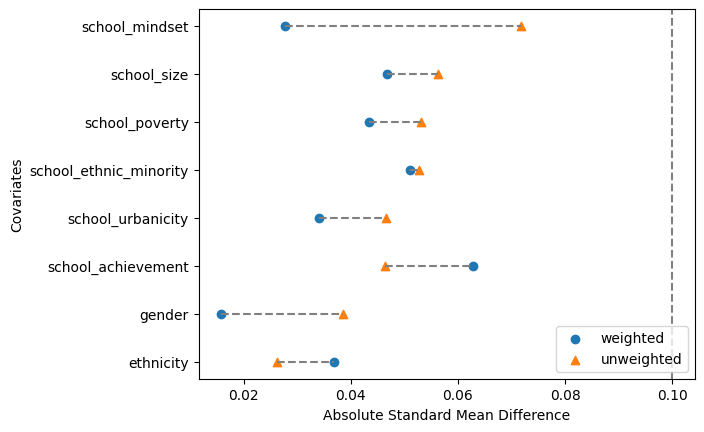

In [17]:
res = evaluate(weight_model, X, T, Y, cv="auto")
res.plot_covariate_balance(kind="love", phase="valid", thresh=0.1)

Weighted이후에 |SMD|가 더 줄어든 것을 보았을 때, Weighted 이후 밸런스가 개선되었음을 확인할 수 있습니다.    
|SMD| < 0.1 이 목표

### Propensity Score Overlap
아래는 처음에 Logistic Regression으로 추정한 Propensity Score의 Distribution을 나타낸 것입니다.

<Axes: title={'center': 'Propensity Distribution'}, xlabel='Propensity', ylabel='Probability density'>

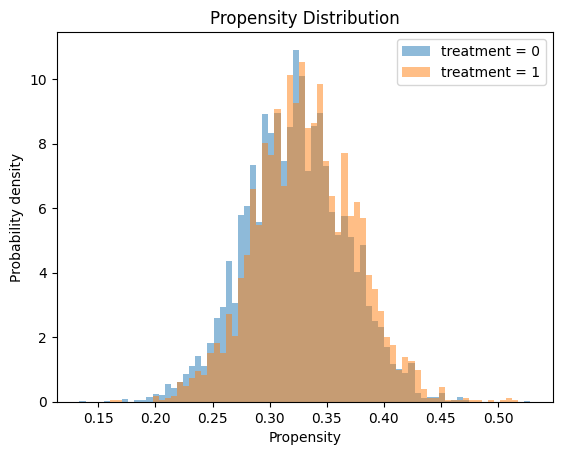

In [18]:
plot_propensity_score_distribution(
    propensity=data_ps['propensity_score'],
    treatment=data_ps['intervention'],
    reflect=False,
    kde=False,
    norm_hist=True,
)

하지만 이는 하나의 데이터에 적합 및 예측을 동시에 하기 때문에 Overlap이 실제보다 좋아보일 수 있습니다.

그렇다면 OOF 폴드 예측으로 얻은 PS 분포를 그려봅시다.   
(cv = None -> 단일 적합, cv = "auto" -> 교차검증)

<Axes: title={'center': 'Propensity Distribution'}, xlabel='Propensity', ylabel='Probability density'>

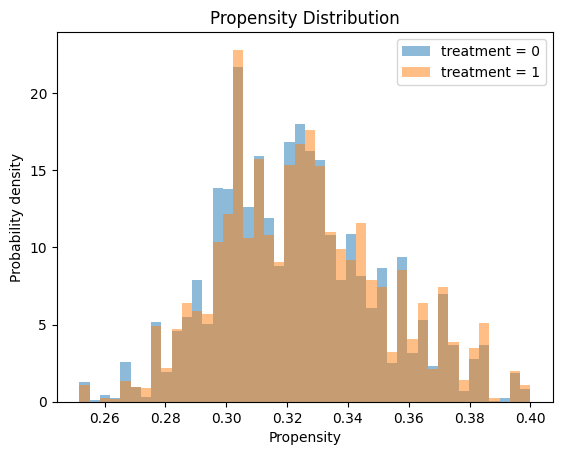

In [19]:
res.plot_weight_distribution(phase="valid", reflect=False, norm_hist=True)

OOF로 검증해도 Propensity Score의 Overlap 및 Positivity가 양호한 것을 확인

### IPW 가중치 분포 및 유효표본수(ESS)

In [20]:
w = weight_model.compute_weights(X, T)
ESS = (w.sum()**2) / (w**2).sum()
N   = len(w)
VIF = N / ESS

print(f"ESS = {ESS:.2f} (N = {N})  ->  VIF = {VIF:.4f}")

ESS = 10354.68 (N = 10391)  ->  VIF = 1.0035


Text(0.5, 1.0, 'IPW weights (log y)')

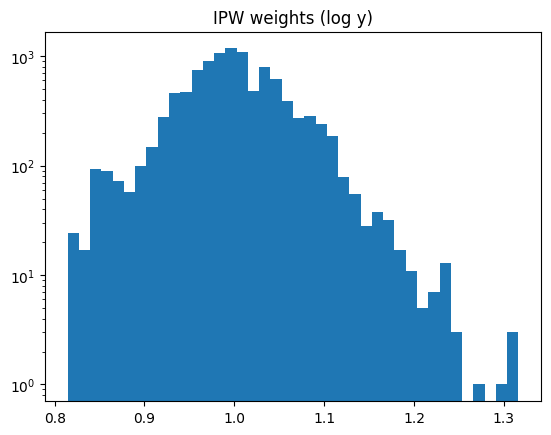

In [21]:
plt.figure(); plt.hist(w, bins=40); plt.yscale('log'); plt.title('IPW weights (log y)')

결과 해석
1) ESS와 N수가 거의 비슷한 것을 확인할 수 있음(VIF ≈ 1) -> 가중치가 고르게 퍼져있다
2) 히스토그램이 1 주변에 모여있고(= 가중치 과도하게 쏠리지 않음), 꼬리 부분도 완만(= 극단 가중치 거의 없음)



다만 VIF와 Propensity Score Overlap이 정량적으로 얼마나 되어야 한다 라는 지표는 찾을 수 없었습니다.    


데이터 및 분석의 맥락에 따라 다르게 지정하되, propensity score의 overlap이 약하다면 위에서 진행한 clipping 등의 방법을 적용해보면 좋습니다. 

[참고자료]
- Yang, Jeff Y., et al. "Propensity score methods to control for confounding in observational cohort studies: a statistical primer and application to endoscopy research." Gastrointestinal endoscopy 90.3 (2019): 360-369.

- Austin, Peter C. "Informing power and sample size calculations when using inverse probability of treatment weighting using the propensity score." Statistics in Medicine 40.27 (2021): 6150-6163.



## Double/Debiased Machine Learning (비모수 버전의 Regression 처럼 활용 가능)

코드 및 데이터 참조 출처: https://matheusfacure.github.io/python-causality-handbook/22-Debiased-Orthogonal-Machine-Learning.html

DML은 ATE와 CATE와 같은 인과적 모수를 구하는 하나의 프레임입니다.   

간략하게 소개하자면, DML은 복잡한 보조모형은 머신러닝으로 학습하고, 직교화(Neyman 점수)와 교차적합으로 bias를 상쇄해 ATE·CATE 같은 인과모수를 정규성으로 안정적으로 추정하는 프레임워크입니다.             
이를 통해 인과 매개변수의 추정 절차와 성가신 매개변수의 추정 절차를 분리할 수 있는 장점을 지닌 방법입니다.

코드와 함께 더 자세하게 알아보기 위해 계량경제학에서 자주 사용하는 데이터셋 중 하나인 **아이스크림 판매 데이터셋**을 활용해보겠습니다.  


In [29]:
test = pd.read_csv("../data/matheus_data/ice_cream_sales_rnd.csv")
train = pd.read_csv("../data/matheus_data/ice_cream_sales.csv")
train.head()

,temp,weekday,cost,price,sales
0,17.3,6,1.5,5.6,173
1,25.4,3,0.3,4.9,196
2,23.3,5,1.5,7.6,207
3,26.9,1,0.3,5.3,241
4,20.2,1,1.0,7.2,227


### Frisch-Waugh-Lovell 응용 DML

In [35]:
y = "sales"
T = "price"
X = ["temp", "weekday", "cost"]

debias_m = LGBMRegressor(max_depth=3, verbosity=-1)
denoise_m = LGBMRegressor(max_depth=3, verbosity=-1)

train_pred = train.assign(price_res =  train[T] - cross_val_predict(debias_m, train[X], train[T], cv=5),
                          sales_res =  train[y] - cross_val_predict(denoise_m, train[X], train[y], cv=5))

위의 코드는 FWL(Frisch-Waugh-Lovell) 정리($Y_i - \mathbb{E}[Y_i\mid X_i] = \tau\,(T_i - \mathbb{E}[T_i\mid X_i]) + \varepsilon$)에서 $ \mathbb{E}[Y_i\mid X_i] $ 와 $\mathbb{E}[T_i\mid X_i] $를 머신러닝을 사용하여 추정합니다.    
-> $Y_i - \mathbb{E}[Y_i\mid X_i] = \tau\,(T_i - \mathbb{E}[T_i\mid X_i]) + \varepsilon$)에서 $

이를 통해 Y와 T의 잔차를 추정할 때 교호작용(변수 간의 Interaction)과 비선형성을 모델링할 수 있고, 동시에 FWL 스타일의 직교화를 유지할 수 있게끔 합니다.     

변수명을 debias_m, 그리고 denoise_m이라고 지정한 이유는 무엇일까요?    

먼저 debias_m은 FWL 정리의 식에서 $T - M_t( = \tilde{T})$부분으로, X의 모든 교란 편향이 모델에 의해 제거된 부분입니다.($M_t := \mathbb{E}[T_i\mid X_i]$를 머신러닝으로 추정한 모델)        
즉, $\tilde{T}$는 X에 직교하는, X로 인한 bias를 없앤 값입니다.    

마찬가지로 denoise_m은 FWL 식에서 $Y - M_y(= \tilde{Y})$부분으로, Y에서 분산을 제거하는 부분입니다.($M_y := \mathbb{E}[Y_i\mid X_i]$를 머신러닝으로 추정한 모델)    
즉, $\tilde{Y}$는 X로 인한 모든 분산이 제거된 값입니다.

위에서 구한 모델을 활용하여 최종 ATE를 구해봅시다.

In [37]:
import statsmodels.formula.api as smf

final_model = smf.ols(formula='sales_res ~ price_res', data=train_pred).fit()
final_model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.0106,0.072,0.148,0.883,-0.131,0.152
price_res,-3.9228,0.071,-54.962,0.000,-4.063,-3.783


위와 같이 최종 ATE 추정 시에는 간단하게 선형으로 ATE를 추정할 수 있습니다.     
    
하지만 이는 결국 True Y값이 비선형적인 모습을 띄고 있다면 ATE를 제대로 추정하지 못하게 되는 단점을 가지고 있습니다.        

그래서 우리는 비모수 이중/탈편향 기계학습 방법을 통해 최종 모델까지도 비선형 ML을 사용하는 방법을 알아볼 것입니다.

#### 비모수 이중/탈편향 기계학습

### 질문이나 의견을 남겨주세요.
<script src="https://utteranc.es/client.js"
        repo="CausalInferenceLab/awesome-causal-inference-python"
        issue-term="pathname"
        theme="github-light"
        crossorigin="anonymous"
        async>
</script>